# Profile likelihood for continuous-time LTI: CD-KF vs CD-EKF vs CD-UKF vs CD-EnKF vs CD-DPF vs D-EKF vs D-EnKF vs D-DPF

This **deep dive** builds a **profile likelihood** and **profile score** for a single parameter (one entry of the drift matrix $A$) in a continuous-time LTI system. All other parameters are **known** (no biases). Controls are simulated i.i.d. from $\mathcal{N}(0,1)$. We compare the profile log-likelihood computed with:

- **CD-KF** (exact continuous-discrete Kalman filter)
- **CD-EKF** (continuous-discrete extended Kalman filter)
- **CD-UKF** (continuous-discrete unscented Kalman filter)
- **CD-EnKF** (continuous-discrete ensemble Kalman filter)
- **CD-DPF** (continuous-discrete differentiable particle filter)
- **D-EKF** (discretize the SDE into a discrete-time state-space model, then run a discrete-time extended Kalman filter)
- **D-EnKF** (discretize the SDE into a discrete-time state-space model, then run a discrete-time ensemble Kalman filter)
- **D-DPF** (discretize the SDE into a discrete-time state-space model, then run a discrete-time differentiable particle filter)

Here **CD-*** means the filter operates directly on the continuous-discrete model: it propagates the latent state between observation times using continuous-time moment or particle evolution, then applies a measurement update when data arrive. By contrast, **D-*** means we first approximate the SDE transition law with a `Discretizer`, producing a discrete-time state-space model (SSM), and then apply an ordinary discrete-time filter to those approximate transition distributions. These are highly related strategies, and often a sigle filtering algorithm can be equivalently expressed in both framings.

**Setup:** 2 states, 1 control, 1 output. We learn $\alpha = A_{0,0}$; $A_{1,1}$ and $L$, $B$, $H$, $R$ are fixed.


## Imports and config

In [1]:
import time

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import Discretizer, Filter, LTI_continuous, SDESimulator
from dynestyx.inference.filters import (
    ContinuousTimeDPFConfig,
    ContinuousTimeEKFConfig,
    ContinuousTimeEnKFConfig,
    ContinuousTimeKFConfig,
    ContinuousTimeUKFConfig,
    EKFConfig,
    EnKFConfig,
    PFConfig,
)

# Dimensions: 2 states, 1 control, 1 output
state_dim = 2
control_dim = 1
observation_dim = 1


## Continuous-time LTI model: one learned parameter $\alpha = A_{0,0}$, no biases

We set

$$
A = \begin{bmatrix} \alpha & 0 \\ 0 & -0.8 \end{bmatrix},
$$

with $L$, $B$, $H$, and $R$ fixed. Biases $b$, $d$ are zero.

For compatibility across all continuous-time filters (including CD-UKF), we set the direct observation-control term $D$ to `None` in this notebook.

In [2]:
def continuous_lti_one_param_model(
    obs_times=None,
    obs_values=None,
    predict_times=None,
    ctrl_times=None,
    ctrl_values=None,
):
    """Continuous-time LTI: only alpha = A[0,0] is sampled; all else fixed."""
    alpha = numpyro.sample("alpha", dist.Uniform(-1.2, 0.2))

    A = jnp.array([[alpha, 0.0], [0.0, -0.8]])
    L = 0.3 * jnp.eye(state_dim)
    H = jnp.array([[1.0, 0.0]])
    R = jnp.array([[0.5**2]])
    B = jnp.array([[0.1], [0.0]])
    D = None

    b = jnp.zeros(state_dim)
    d = jnp.zeros(observation_dim)

    initial_mean = jnp.zeros(state_dim)
    initial_cov = jnp.eye(state_dim)

    dynamics = LTI_continuous(
        A=A,
        L=L,
        H=H,
        R=R,
        B=B,
        b=b,
        D=D,
        d=d,
        initial_mean=initial_mean,
        initial_cov=initial_cov,
    )

    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )

## True parameter, observation times, and controls $u_t \sim \mathcal{N}(0,1)$

Controls are provided on the same grid as observation times.

In [3]:
true_alpha = -0.4
obs_times = jnp.arange(0.0, 20.0, 0.1)
T = len(obs_times)

key = jr.PRNGKey(42)
key_ctrl, key_data = jr.split(key)

# Controls i.i.d. N(0,1)
ctrl_values = jr.normal(key_ctrl, shape=(T, control_dim))
ctrl_times = obs_times

print("True alpha:", true_alpha)
print("Observation times length:", T)
print("Controls shape:", ctrl_values.shape)

True alpha: -0.4
Observation times length: 200
Controls shape: (200, 1)


## Generate synthetic observations

Simulate the model with true $\alpha$ and the control trajectory to get $y_{1:T}$.

In [4]:
predictive = Predictive(
    continuous_lti_one_param_model,
    params={"alpha": jnp.array(true_alpha)},
    num_samples=1,
    exclude_deterministic=False,
)

with SDESimulator(dt0=1e-2):
    synthetic = predictive(
        key_data,
        predict_times=obs_times,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )

obs_values = synthetic["f_observations"].squeeze(0).squeeze(0)
print("Observations shape:", obs_values.shape)

Observations shape: (200, 1)


## Profile log-likelihood

For each filter type (CD-KF, CD-EKF, CD-UKF, CD-EnKF, CD-DPF, D-EKF, D-EnKF, D-DPF), we compute $\log p(y_{1:T} \mid \alpha)$ by running `Predictive` with `params={"alpha": alpha}`. The marginal log-likelihood is the `f_marginal_loglik` deterministic site. We `vmap` over the grid of $\alpha$ values.


**Note:** CD-EnKF, CD-DPF, D-EnKF, and D-DPF profiles are stochastic (one random key per run). Re-run those cells with a different key to see variability. CD-KF is deterministic for this linear-Gaussian model, and CD-EKF / CD-UKF / D-EKF are deterministic given fixed settings.


In [5]:
alpha_min, alpha_max = -1.0, 0.1
n_grid = 61
alpha_grid = jnp.linspace(alpha_min, alpha_max, n_grid)


def make_model(filter_type):
    """Build data-conditioned model with either a CD filter or D filter."""
    config = {
        "kf": ContinuousTimeKFConfig(warn=False),
        "ekf": ContinuousTimeEKFConfig(warn=False),
        "ukf": ContinuousTimeUKFConfig(warn=False),
        "enkf": ContinuousTimeEnKFConfig(
            n_particles=100,
            perturb_measurements=True,
            inflation_delta=0.00,
            warn=False,
        ),
        "dpf": ContinuousTimeDPFConfig(n_particles=500, warn=False),
        "dekf": EKFConfig(warn=False),
        "denkf": EnKFConfig(
            n_particles=100,
            perturb_measurements=True,
            inflation_delta=0.00,
            warn=False,
        ),
        "ddpf": PFConfig(n_particles=500, warn=False),
    }[filter_type]
    use_discretizer = filter_type in {"dekf", "denkf", "ddpf"}

    def model():
        with Filter(filter_config=config):
            if use_discretizer:
                with Discretizer():
                    return continuous_lti_one_param_model(
                        obs_times=obs_times,
                        obs_values=obs_values,
                        ctrl_times=ctrl_times,
                        ctrl_values=ctrl_values,
                    )
            return continuous_lti_one_param_model(
                obs_times=obs_times,
                obs_values=obs_values,
                ctrl_times=ctrl_times,
                ctrl_values=ctrl_values,
            )

    return model


def get_marginal_loglik(alpha_val, key, filter_type):
    """Run Predictive with fixed alpha; return f_marginal_loglik site."""
    model = make_model(filter_type)
    pred = Predictive(
        model,
        params={"alpha": jnp.array(alpha_val)},
        num_samples=1,
        exclude_deterministic=False,
    )
    out = pred(key)
    return out["f_marginal_loglik"].squeeze()


def profile_log_likelihood(filter_type, alpha_vals, key=jr.PRNGKey(0)):
    """Profile log p(y | alpha) via vmap over Predictive + f_marginal_loglik."""
    keys = jr.split(key, len(alpha_vals))
    t0 = time.perf_counter()
    profile = jax.vmap(
        lambda a, k: get_marginal_loglik(a, k, filter_type),
        in_axes=(0, 0),
    )(alpha_vals, keys)
    elapsed = time.perf_counter() - t0
    return profile, elapsed


## Plot profile log-likelihoods

All methods should peak near the true $\alpha = -0.4$. CD-KF is exact for this linear-Gaussian continuous-discrete model; CD-EKF and CD-UKF are approximate continuous-discrete filters that should also match closely in this linear case. The discretized variants first approximate the SDE as a discrete-time SSM and then filter that approximation. CD-EnKF, CD-DPF, D-EnKF, and D-DPF are Monte Carlo approximations.


In [6]:
profile_kf, t_kf = profile_log_likelihood("kf", alpha_grid, jr.PRNGKey(10))
profile_ekf, t_ekf = profile_log_likelihood("ekf", alpha_grid, jr.PRNGKey(11))
profile_ukf, t_ukf = profile_log_likelihood("ukf", alpha_grid, jr.PRNGKey(12))
profile_enkf, t_enkf = profile_log_likelihood("enkf", alpha_grid, jr.PRNGKey(13))
profile_dpf, t_dpf = profile_log_likelihood("dpf", alpha_grid, jr.PRNGKey(14))
profile_dekf, t_dekf = profile_log_likelihood("dekf", alpha_grid, jr.PRNGKey(15))
profile_denkf, t_denkf = profile_log_likelihood("denkf", alpha_grid, jr.PRNGKey(16))
profile_ddpf, t_ddpf = profile_log_likelihood("ddpf", alpha_grid, jr.PRNGKey(17))

method_order = [
    "CD-KF",
    "CD-EKF",
    "CD-UKF",
    "CD-EnKF",
    "CD-DPF",
    "D-EKF",
    "D-EnKF",
    "D-DPF",
]
method_colors = {
    "CD-KF": "C0",
    "CD-EKF": "C1",
    "CD-UKF": "C2",
    "CD-EnKF": "C3",
    "CD-DPF": "C4",
    "D-EKF": "C5",
    "D-EnKF": "C6",
    "D-DPF": "C7",
}

timings = {
    "CD-KF": t_kf,
    "CD-EKF": t_ekf,
    "CD-UKF": t_ukf,
    "CD-EnKF": t_enkf,
    "CD-DPF": t_dpf,
    "D-EKF": t_dekf,
    "D-EnKF": t_denkf,
    "D-DPF": t_ddpf,
}
profiles = {
    "CD-KF": profile_kf,
    "CD-EKF": profile_ekf,
    "CD-UKF": profile_ukf,
    "CD-EnKF": profile_enkf,
    "CD-DPF": profile_dpf,
    "D-EKF": profile_dekf,
    "D-EnKF": profile_denkf,
    "D-DPF": profile_ddpf,
}

print("Filter     | max profile ll  | time (s)")
print("-----------|-----------------|--------")
for name in method_order:
    ll = float(jnp.nanmax(profiles[name]))
    print(f"{name:10} | {ll:15.4f} | {timings[name]:.3f}")


/Users/levinema/Projects/research/dynestyx/dynestyx/inference/integrations/cd_dynamax/utils.py:127: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return _CallableFunction(fn=value)


Filter     | max profile ll  | time (s)
-----------|-----------------|--------
CD-KF      |       -163.0877 | 1.955
CD-EKF     |       -163.0877 | 0.784
CD-UKF     |       -163.0877 | 1.164
CD-EnKF    |       -162.3120 | 2.089
CD-DPF     |       -162.6935 | 38.666
D-EKF      |       -163.0730 | 3.261
D-EnKF     |       -162.6247 | 1.272
D-DPF      |       -162.7855 | 3.679


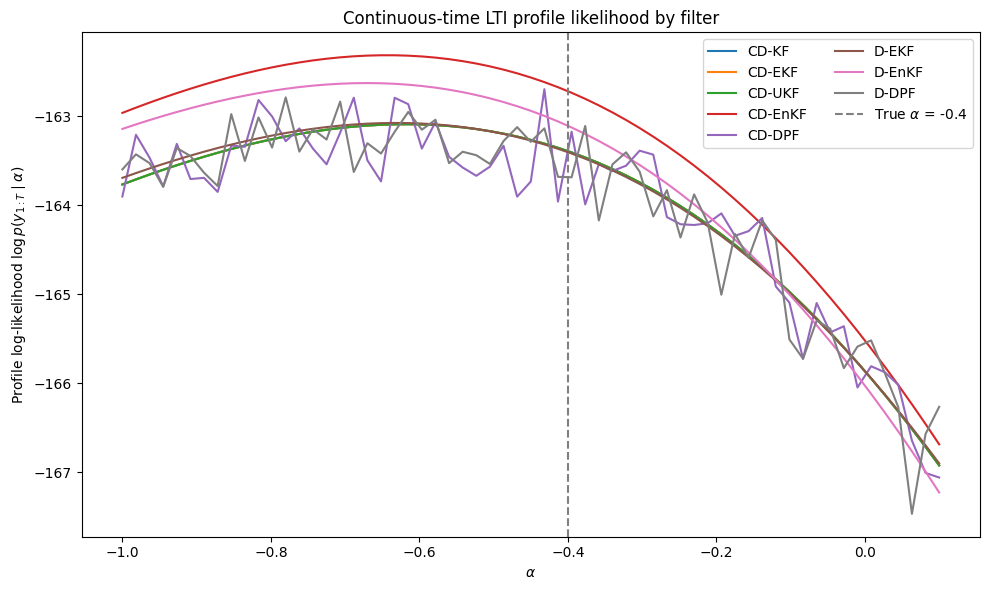

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for name in method_order:
    ax.plot(
        np.array(alpha_grid),
        np.array(profiles[name]),
        label=name,
        color=method_colors[name],
    )
ax.axvline(true_alpha, color="gray", linestyle="--", label=f"True $\\alpha$ = {true_alpha}")
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("Profile log-likelihood $\\log p(y_{1:T} \\mid \\alpha)$")
ax.legend(ncol=2)
ax.set_title("Continuous-time LTI profile likelihood by filter")
plt.tight_layout()
plt.show()


## Deviation from CD-KF

Since CD-KF is exact for this linear-Gaussian continuous-discrete problem, it is the natural reference. To summarize how the other methods deviate from the optimal profile, we compare each method's profile log-likelihood against CD-KF pointwise over the full $\alpha$ grid.

Below we compute signed deviations, absolute deviations, and a few compact summaries:

- **MAE**: mean absolute deviation across the profile grid
- **RMSE**: root-mean-squared deviation across the profile grid
- **Max abs**: worst-case absolute deviation anywhere on the profile

The plot then gives each method its own x-axis column, with the vertical spread showing the distribution of absolute deviations across the whole profile.


In [8]:
reference_name = "CD-KF"
comparison_names = [name for name in profiles.keys() if name != reference_name]

profile_signed_deviations = {
    name: np.array(profiles[name] - profiles[reference_name])
    for name in comparison_names
}
profile_abs_deviations = {
    name: np.abs(vals) for name, vals in profile_signed_deviations.items()
}

profile_error_summary = {}
for name in comparison_names:
    abs_dev = profile_abs_deviations[name]
    signed_dev = profile_signed_deviations[name]
    profile_error_summary[name] = {
        "mae": float(np.mean(abs_dev)),
        "rmse": float(np.sqrt(np.mean(signed_dev**2))),
        "max_abs": float(np.max(abs_dev)),
        "median_abs": float(np.median(abs_dev)),
    }

print("Method    | MAE        | RMSE       | Median abs | Max abs")
print("----------|------------|------------|------------|--------")
for name in comparison_names:
    stats = profile_error_summary[name]
    print(
        f"{name:9} | {stats['mae']:10.6f} | {stats['rmse']:10.6f} | "
        f"{stats['median_abs']:10.6f} | {stats['max_abs']:8.6f}"
    )


Method    | MAE        | RMSE       | Median abs | Max abs
----------|------------|------------|------------|--------
CD-EKF    |   0.000000 |   0.000000 |   0.000000 | 0.000000
CD-UKF    |   0.000000 |   0.000000 |   0.000000 | 0.000000
CD-EnKF   |   0.637978 |   0.662018 |   0.701652 | 0.811903
CD-DPF    |   0.265567 |   0.320941 |   0.237513 | 0.675588
D-EKF     |   0.023083 |   0.030163 |   0.017522 | 0.074284
D-EnKF    |   0.332551 |   0.382835 |   0.326689 | 0.624787
D-DPF     |   0.256031 |   0.322023 |   0.198870 | 0.953776


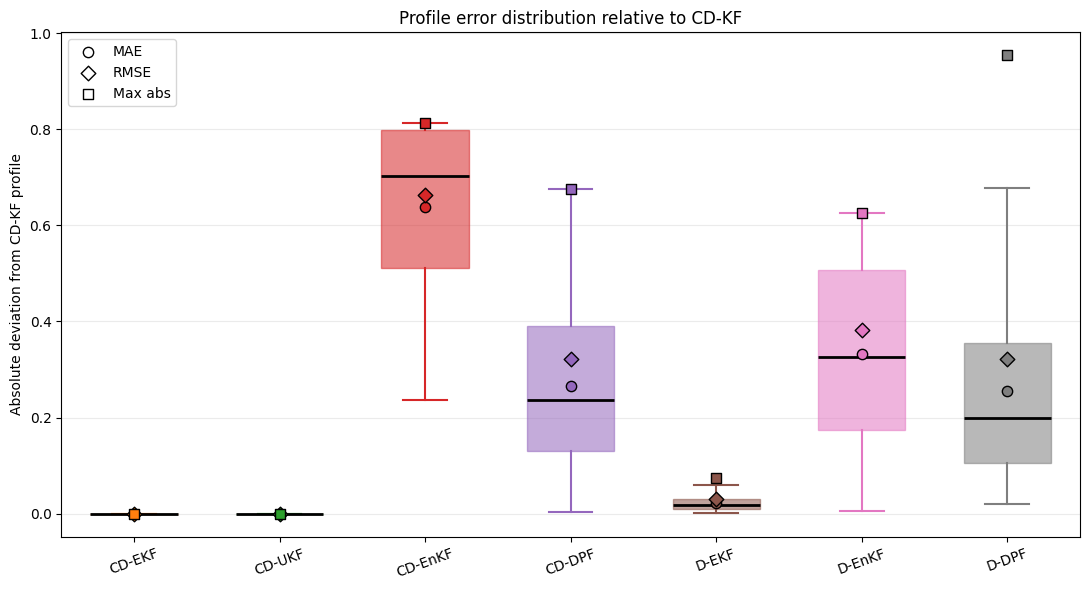

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(11, 6))

positions = np.arange(1, len(comparison_names) + 1)

for pos, name in zip(positions, comparison_names):
    color = method_colors[name]
    abs_dev = profile_abs_deviations[name]

    ax.boxplot(
        [abs_dev],
        positions=[pos],
        widths=0.6,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor=color, edgecolor=color, alpha=0.55),
        whiskerprops=dict(color=color, linewidth=1.5),
        capprops=dict(color=color, linewidth=1.5),
        medianprops=dict(color="black", linewidth=2),
    )

    stats = profile_error_summary[name]
    ax.scatter(
        pos,
        stats["mae"],
        color=color,
        edgecolor="black",
        marker="o",
        s=55,
        zorder=3,
    )
    ax.scatter(
        pos,
        stats["rmse"],
        color=color,
        edgecolor="black",
        marker="D",
        s=55,
        zorder=3,
    )
    ax.scatter(
        pos,
        stats["max_abs"],
        color=color,
        edgecolor="black",
        marker="s",
        s=55,
        zorder=3,
    )

ax.scatter([], [], color="white", edgecolor="black", marker="o", s=55, label="MAE")
ax.scatter([], [], color="white", edgecolor="black", marker="D", s=55, label="RMSE")
ax.scatter([], [], color="white", edgecolor="black", marker="s", s=55, label="Max abs")

ax.set_xticks(positions)
ax.set_xticklabels(comparison_names, rotation=20)
ax.set_ylabel(r"Absolute deviation from CD-KF profile")
ax.set_title("Profile error distribution relative to CD-KF")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


The profile plot above gives a quick visual check of estimator agreement. In this run, the deterministic Gaussian methods (CD-KF, CD-EKF, CD-UKF, D-EKF) should largely overlap on this linear problem. The Monte Carlo methods (CD-EnKF, CD-DPF, D-EnKF, D-DPF) can show seed-to-seed variation, and the discretized variants let us see how much of the behavior comes from filtering versus from the continuous-to-discrete approximation step.


## Profile Score

For each filter type (CD-KF, CD-EKF, CD-UKF, CD-EnKF, CD-DPF, D-EKF, D-EnKF, D-DPF), we can also compute $\nabla_\alpha \log p(y_{1:T} \mid \alpha)$ with direct auto-differentiation. The code to do this is simply wrapping `jax.grad` around the MLL profiles.


In [10]:
def profile_score(filter_type, alpha_vals, key=jr.PRNGKey(0)):
    """Profile score d/dalpha log p(y | alpha) via vmap + autodiff."""
    keys = jr.split(key, len(alpha_vals))
    t0 = time.perf_counter()
    get_score = jax.jit(
        lambda a, k: jax.grad(get_marginal_loglik)(a, k, filter_type)
    )
    profile = jax.vmap(
        lambda a, k: get_score(a, k),
        in_axes=(0, 0),
    )(alpha_vals, keys)
    elapsed = time.perf_counter() - t0
    return profile, elapsed

In [11]:
score_kf, ts_kf = profile_score("kf", alpha_grid, jr.PRNGKey(20))
score_ekf, ts_ekf = profile_score("ekf", alpha_grid, jr.PRNGKey(21))
score_ukf, ts_ukf = profile_score("ukf", alpha_grid, jr.PRNGKey(22))
score_enkf, ts_enkf = profile_score("enkf", alpha_grid, jr.PRNGKey(23))
score_dpf, ts_dpf = profile_score("dpf", alpha_grid, jr.PRNGKey(24))
score_dekf, ts_dekf = profile_score("dekf", alpha_grid, jr.PRNGKey(25))
score_denkf, ts_denkf = profile_score("denkf", alpha_grid, jr.PRNGKey(26))
score_ddpf, ts_ddpf = profile_score("ddpf", alpha_grid, jr.PRNGKey(27))

score_timings = {
    "CD-KF": ts_kf,
    "CD-EKF": ts_ekf,
    "CD-UKF": ts_ukf,
    "CD-EnKF": ts_enkf,
    "CD-DPF": ts_dpf,
    "D-EKF": ts_dekf,
    "D-EnKF": ts_denkf,
    "D-DPF": ts_ddpf,
}
score_profiles = {
    "CD-KF": score_kf,
    "CD-EKF": score_ekf,
    "CD-UKF": score_ukf,
    "CD-EnKF": score_enkf,
    "CD-DPF": score_dpf,
    "D-EKF": score_dekf,
    "D-EnKF": score_denkf,
    "D-DPF": score_ddpf,
}

print("Filter     | max score       | time (s)")
print("-----------|-----------------|--------")
for name in method_order:
    sc = float(jnp.nanmax(score_profiles[name]))
    print(f"{name:10} | {sc:15.4f} | {score_timings[name]:.3f}")


/Users/levinema/Projects/research/dynestyx/dynestyx/inference/integrations/cd_dynamax/utils.py:127: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return _CallableFunction(fn=value)


Filter     | max score       | time (s)
-----------|-----------------|--------
CD-KF      |          3.1576 | 4.284
CD-EKF     |          3.1576 | 3.605
CD-UKF     |          3.1576 | 4.193
CD-EnKF    |          3.2716 | 5.602
CD-DPF     |          4.3489 | 78.235
D-EKF      |          2.9953 | 2.147
D-EnKF     |          2.8232 | 1.252
D-DPF      |          5.7669 | 2.582


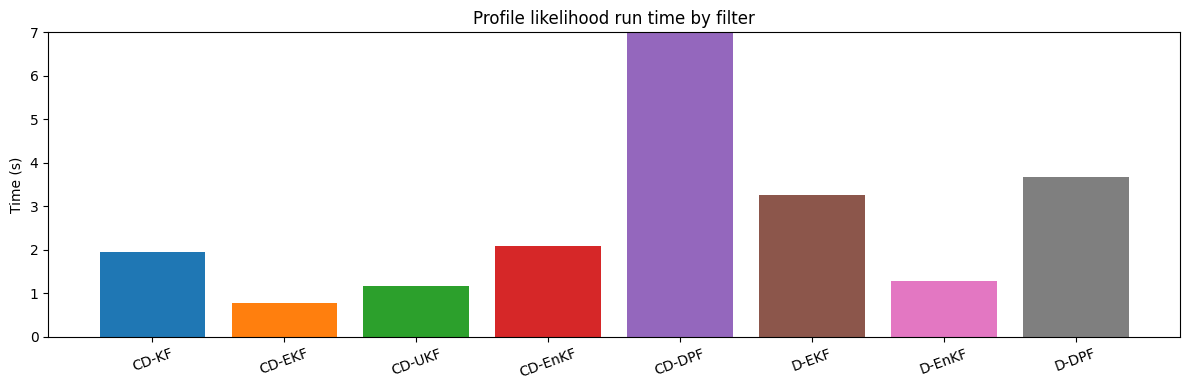

In [15]:
# Bar chart of profile likelihood run times
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
names = method_order
times = [timings[n] for n in names]
ax.bar(names, times, color=[method_colors[n] for n in names])
ax.set_ylabel("Time (s)")
ax.set_ylim([0, 7])
ax.set_title("Profile likelihood run time by filter")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


The takeaways are similar for the score example: the continuous-discrete and discretized Gaussian filters should agree closely on this linear problem, while the EnKF and DPF variants expose Monte Carlo variability. Comparing CD-EnKF against D-EnKF, and CD-DPF against D-DPF, helps separate approximation error from the extra discretization step.


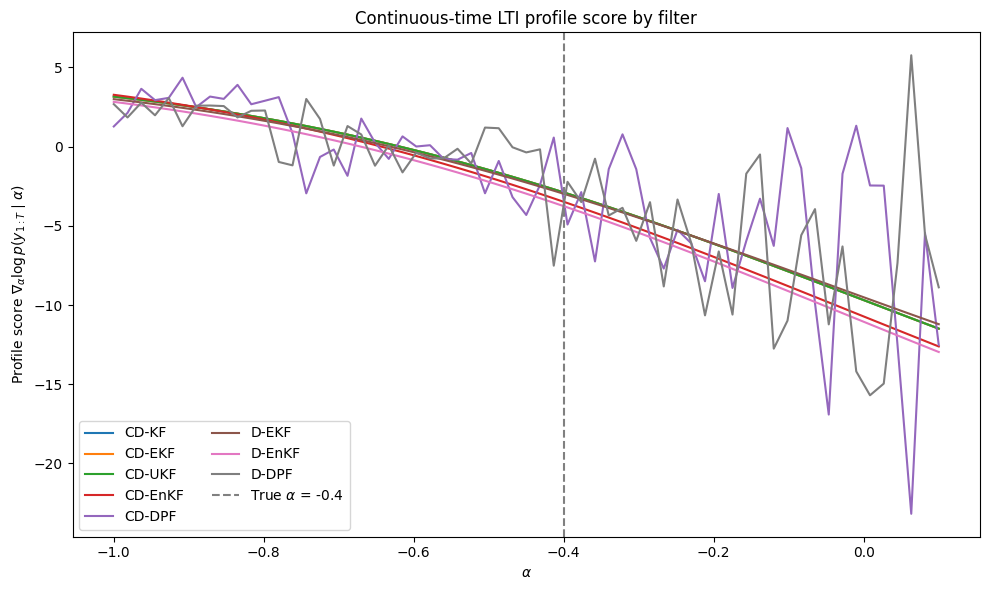

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for name in method_order:
    ax.plot(
        np.array(alpha_grid),
        np.array(score_profiles[name]),
        label=name,
        color=method_colors[name],
    )
ax.axvline(true_alpha, color="gray", linestyle="--", label=f"True $\\alpha$ = {true_alpha}")
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("Profile score $\\nabla_\\alpha \\log p(y_{1:T} \\mid \\alpha)$")
ax.legend(ncol=2)
ax.set_title("Continuous-time LTI profile score by filter")
plt.tight_layout()
plt.show()
